In [33]:
# import metric

In [34]:
import vtracer
from IPython.display import SVG, display, Image
from PIL import Image as PILImage
input_path = "test5.png"
output_path = "output.svg"
img = PILImage.open(input_path)

In [35]:
import re


def scale_svg_to_384(svg_code: str, size: int) -> str:
    scale_factor = 384 / size  # 1.5x

    # 1. Scale numbers inside path d="..."
    def scale_path_d(match):
        path_content = match.group(1)
        scaled_content = re.sub(
            r'-?\d+\.?\d*',
            lambda m: str(int(round(float(m.group()) * scale_factor))),
            path_content
        )
        return f'd="{scaled_content}"'

    svg_code = re.sub(r'd="([^"]+)"', scale_path_d, svg_code)

    # 2. Scale translate(x, y) values
    def scale_translate(match):
        x, y = match.group(1), match.group(2)
        x_scaled = int(round(float(x) * scale_factor))
        y_scaled = int(round(float(y) * scale_factor))
        return f'translate({x_scaled},{y_scaled})'

    svg_code = re.sub(r'translate\(\s*([-\d.]+)[ ,]([-\d.]+)\s*\)', scale_translate, svg_code)

    # 3. Scale basic shape attributes
    def scale_single_value_attributes(svg_code, attr_name):
        pattern = fr'({attr_name}=")(-?\d+\.?\d*)(")'
        return re.sub(
            pattern,
            lambda m: f'{m.group(1)}{int(round(float(m.group(2)) * scale_factor))}{m.group(3)}',
            svg_code
        )

    for attr in ['x', 'y', 'width', 'height', 'cx', 'cy', 'r', 'rx', 'ry']:
        svg_code = scale_single_value_attributes(svg_code, attr)

    return svg_code


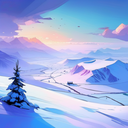

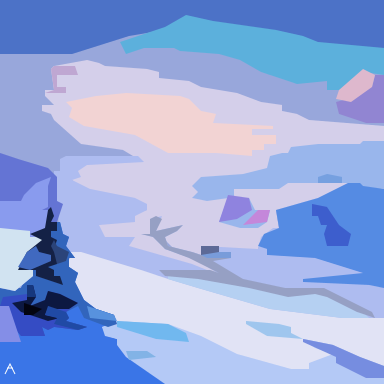

<svg viewBox="0 0 384 384" width="384" height="384">
<path d="M0,0 L384,0 L384,384 L0,384 Z " fill="#98A7DB" transform="translate(0,0)"/>
<path d="M0,0 L12,3 L18,6 L60,9 L72,12 L72,18 L102,21 L114,27 L150,33 L174,42 L195,45 L195,51 L210,54 L222,60 L297,66 L297,129 L276,126 L264,123 L240,138 L213,147 L189,150 L192,168 L174,180 L171,189 L132,189 L114,186 L114,195 L87,189 L75,177 L81,171 L78,171 L69,171 L72,159 L63,159 L63,174 L75,180 L78,189 L111,198 L141,216 L132,219 L123,213 L72,198 L36,186 L39,180 L18,180 L12,174 L12,165 L18,162 L48,162 L48,156 L42,153 L60,150 L57,144 L24,135 L-6,129 L-18,117 L-9,114 L-15,108 L0,102 L51,99 L36,90 L-6,84 L-33,60 L-36,54 L-45,51 L-45,45 L-33,45 L-42,36 L-42,30 L-33,30 L-36,9 L-33,6 Z " fill="#D4CFEA" transform="translate(87,60)"/>
<path d="M0,0 L18,3 L96,24 L120,33 L189,54 L240,63 L315,69 L315,135 L96,135 L57,108 L48,96 L48,90 L36,87 L33,78 L48,75 L42,66 L24,60 L9,48 L3,27 L6,24 L-3,15 L3,6 Z " fill="#E1E3F5" transform="translate(69,249)"/>
<path d="M0,

In [36]:
# !pip install vtracer pillow
import vtracer
from IPython.display import SVG, display, Image
from PIL import Image as PILImage

def bitmap_to_svg_layered(img, input_path, output_path):
    
    # Define input and output paths
    # (input_path and output_path are already passed as arguments)

    # Step 1: Resize the input image to 256x256
    # 256x256 is helpful bc each length od path is shorter, so with the same max_svg_length, we can have more paths(more color)
    size = 128
    img = img.resize((size,size), PILImage.LANCZOS)
    img.save(input_path)

    # Step 2: Convert the resized image to SVG
    layer_difference = 10  # initial value
    max_svg_length = 9996  # target length limit

    # Define injection to prevent OCR hallucination
    injection = '<path d="M5 374 L10 364 L15 374 M7 368 L13 368" stroke="white" fill="none"/>'
    injection_length = len(injection)

    while True:
        vtracer.convert_image_to_svg_py(
            input_path,
            output_path,
            colormode='color',        # Options: 'color' or 'binary'
            hierarchical='stacked',   # Options: 'stacked' or 'cutout'
            mode='polygon',           # Options: 'spline', 'polygon', or 'none'
            filter_speckle=3,          # remove tiny regions
            color_precision=8,         # reduce color complexity
            layer_difference=layer_difference,  # more aggressive merging
            corner_threshold=10,       # remove subtle corners
            length_threshold=10,       # remove short paths
            max_iterations=10,         # faster, less detail
            splice_threshold=10,       # simplify curves
            path_precision=3           # reduce vertex detail
        )

        # Step 3: Read and display the SVG
        with open(output_path, "r", encoding="utf-8") as f:
            svg_code = f.read()

        # Clean the first two lines if present
        lines = svg_code.splitlines()
        removed_length = 0
        if lines and lines[0].strip().startswith('<?xml'):
            removed_length += len(lines[0]) + 1  # +1 for newline
            lines = lines[1:]
        if lines and lines[0].strip().startswith('<!--'):
            removed_length += len(lines[0]) + 1  # +1 for newline
            lines = lines[1:]
        svg_code = "\n".join(lines)

        svg_code = svg_code.replace(
            '<svg ',
            '<svg viewBox="0 0 384 384" ', #this is 20 bytes more
            1  # only replace first occurrence
        )

        svg_code = scale_svg_to_384(svg_code, size)

        # remove version and xmlns attributes
        svg_code = re.sub(r'\s*version="[^"]*"', '', svg_code)
        svg_code = re.sub(r'\s*xmlns="[^"]*"', '', svg_code)

        # Correct length check: give credit for removed lines
        if len(svg_code) + injection_length <= max_svg_length:
            break
        else:
            layer_difference += 10
        
    # Inject fake letter path to prevent OCR hallucination
    svg_code = svg_code.replace("</svg>", injection + "</svg>")


    return svg_code

svg_code = bitmap_to_svg_layered(img, input_path, output_path)

# Show the original PNG (resized)
display(Image(filename=input_path))

# Show the SVG result
display(SVG(svg_code))

# Print raw SVG XML code and its length
print(svg_code)
print(len(svg_code))
print(len(svg_code.splitlines()))